# Exploratory Data Analysis: Environmental and Power Consumption Dataset
This notebook explores a time series dataset with timestamped readings for temp, humidity, windspeed, diffuse flows, genral diffuse flows and power consumption across three zones.
The analysis includes data cleaning, quality checks, trend analysis, correlations , scatter plots and breakdown of power usage per zone
### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,6)
plt.rcParams["figure.dpi"]=100
plt.rcParams["font.family"] = "DejaVu Sans"
%matplotlib inline

### 2. Load the Dataset

In [26]:
df = pd.read_csv(r"C:\Users\push\Documents\PYTHON DA PROJECTS\Electricity+Consumption\powerconsumption.csv")
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns") #checking for the shape of the dataset
df.columns = (df.columns.str.strip().str.title().str.replace(" ", "_")) #changing the text format of all the columns to this example -  fisrt_col
df = df.map(lambda x: x.title() if isinstance(x, str) else x) #capitalizing the first letter for all the values in each rows
pd.set_option("display.float_format", "{:,.3f}".format)
df.head(10)

There are 52416 rows and 9 columns


,Datetime,Temperature,Humidity,Windspeed,Generaldiffuseflows,Diffuseflows,Powerconsumption_Zone1,Powerconsumption_Zone2,Powerconsumption_Zone3
0,2017-01-01 00:00:00,6.559,73.800,0.083,0.051,0.119,"34,055.696","16,128.875","20,240.964"
1,2017-01-01 00:10:00,6.414,74.500,0.083,0.070,0.085,"29,814.684","19,375.076","20,131.084"
2,2017-01-01 00:20:00,6.313,74.500,0.080,0.062,0.100,"29,128.101","19,006.687","19,668.434"
3,2017-01-01 00:30:00,6.121,75.000,0.083,0.091,0.096,"28,228.861","18,361.094","18,899.277"
4,2017-01-01 00:40:00,5.921,75.700,0.081,0.048,0.085,"27,335.696","17,872.340","18,442.410"
5,2017-01-01 00:50:00,5.853,76.900,0.081,0.059,0.108,"26,624.810","17,416.413","18,130.120"
6,2017-01-01 01:00:00,5.641,77.700,0.080,0.048,0.096,"25,998.987","16,993.313","17,945.060"
7,2017-01-01 01:10:00,5.496,78.200,0.085,0.055,0.093,"25,446.076","16,661.398","17,459.277"
8,2017-01-01 01:20:00,5.678,78.100,0.081,0.066,0.141,"24,777.722","16,227.356","17,025.542"
9,2017-01-01 01:30:00,5.491,77.300,0.082,0.062,0.111,"24,279.494","15,939.210","16,794.217"


### 3. Data Overview

In [27]:
#rename some of the column head
df.rename(columns={
    "Temperature" : "Temp_℃",
    "Generaldiffuseflows" : "General_Diffuse_Flows",
    "Diffuseflows" : "Diffuse_Flows",
    "Powerconsumption_Zone1" : "Power_Consumption_kWh_Zone1",
    "Powerconsumption_Zone2" : "Power_Consumption_kWh_Zone2",
    "Powerconsumption_Zone3" : "Power_Consumption_kWh_Zone3"
}, inplace=True)
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Datetime                     52416 non-null  str    
 1   Temp_℃                       52416 non-null  float64
 2   Humidity                     52416 non-null  float64
 3   Windspeed                    52416 non-null  float64
 4   General_Diffuse_Flows        52416 non-null  float64
 5   Diffuse_Flows                52416 non-null  float64
 6   Power_Consumption_kWh_Zone1  52416 non-null  float64
 7   Power_Consumption_kWh_Zone2  52416 non-null  float64
 8   Power_Consumption_kWh_Zone3  52416 non-null  float64
dtypes: float64(8), str(1)
memory usage: 4.5 MB


In [28]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

#### Dataset Describtion
| Field | Description |
| ----- | ----------- |
| Datetime | The date and time of the recording |
| Temp_℃ | The Temperature in Celsius |
| Humidity | The concentration of water vapor in the air |
| WindSpeed | The speed of the wind in kilometers per hour |
| General_Diffuse_Flows | The measurement of how much emissions gases diffuse into the broader atmosphere |
| Diffuse_Flows | The measurement of how much emissions gases diffuse into the local atmosphere |
| Power_Consumption_kWh_Zone1 | The power consumption in Kilowatt-Hours in Power Zone 1 |
| Power_Consumption_kWh_Zone2 | The power consumption in Kilowatt-Hours in Power Zone 2 |
| Power_Consumption_kWh_Zone3 | The power consumption in Kilowatt-Hours in Power Zone 3 |


In [29]:
#check for duplicatd rows
df.duplicated(keep="first").sum()

np.int64(0)

In [30]:
#reducing number of rows by using avg readings for when the datetime interval is 1hr
df_hourly_avg = df.set_index("Datetime").resample("1h").mean().round(3).reset_index()
print(f"Number of rows are now {df_hourly_avg.shape[0]}")
df_hourly_avg.head()

Number of rows are now 8736


,Datetime,Temp_℃,Humidity,Windspeed,General_Diffuse_Flows,Diffuse_Flows,Power_Consumption_kWh_Zone1,Power_Consumption_kWh_Zone2,Power_Consumption_kWh_Zone3
0,2017-01-01 00:00:00,6.197,75.067,0.082,0.064,0.099,"29,197.975","18,026.748","19,252.048"
1,2017-01-01 01:00:00,5.549,77.583,0.082,0.057,0.112,"24,657.215","16,078.419","17,042.892"
2,2017-01-01 02:00:00,5.054,78.933,0.082,0.063,0.129,"22,083.038","14,330.699","15,676.145"
3,2017-01-01 03:00:00,5.004,77.083,0.083,0.060,0.141,"20,811.139","13,219.453","14,883.855"
4,2017-01-01 04:00:00,5.098,74.050,0.082,0.058,0.123,"20,475.949","12,921.581","14,317.108"


In [31]:
df_hourly_agg = df.set_index("Datetime").resample("1h").agg({
    "Temp_℃":"mean",
    "Humidity":"mean",
    "Windspeed":"mean",
    "General_Diffuse_Flows":"mean",
    "Diffuse_Flows":"mean",
    "Power_Consumption_kWh_Zone1":["mean", "min", "max"],
    "Power_Consumption_kWh_Zone2":["mean", "min", "max"],
    "Power_Consumption_kWh_Zone3":["mean", "min", "max"]
}
).round(3).reset_index()
print(f"Number of rows are now {df_hourly_agg.shape[0]} and number of columns are {df_hourly_agg.shape[1]}")
df_hourly_agg.head()

Number of rows are now 8736 and number of columns are 15


Datetime Temp_℃ Humidity Windspeed General_Diffuse_Flows  \
                        mean     mean      mean                  mean   
0 2017-01-01 00:00:00  6.197   75.067     0.082                 0.064   
1 2017-01-01 01:00:00  5.549   77.583     0.082                 0.057   
2 2017-01-01 02:00:00  5.054   78.933     0.082                 0.063   
3 2017-01-01 03:00:00  5.004   77.083     0.083                 0.060   
4 2017-01-01 04:00:00  5.098   74.050     0.082                 0.058   

  Diffuse_Flows Power_Consumption_kWh_Zone1                        \
           mean                        mean        min        max   
0         0.099                  29,197.975 26,624.810 34,055.696   
1         0.112                  24,657.215 23,544.304 25,998.987   
2         0.129                  22,083.038 21,484.557 23,003.544   
3         0.141                  20,811.139 20,421.266 21,107.848   
4         0.123                  20,475.949 20,311.899 20,530.633   

  Power_Consumption_kWh_Zone2                        \
                         mean        min        max   
0                  18,026.748 16,128.875 19,375.076   
1                  16,078.419 15,213.374 16,993.313   
2                  14,330.699 13,612.158 15,169.605   
3                  13,219.453 12,908.207 13,535.562   
4                  12,921.581 12,820.669 13,032.219   

  Power_Consumption_kWh_Zone3                        
                         mean        min        max  
0                  19,252.048 18,130.120 20,240.964  
1                  17,042.892 16,395.181 17,945.060  
2                  15,676.145 15,336.867 16,117.590  
3                  14,883.855 14,590.843 15,140.241  
4                  14,317.108 14,157.108 14,585.060

In [32]:
#reducing number of rows by using exact readings for when the datetime interval is 1hr
df_hourly = df.iloc[::6].reset_index(drop=True)
print(f"Number of rows are now {df_hourly.shape[0]}")
df_hourly.head()

Number of rows are now 8736


,Datetime,Temp_℃,Humidity,Windspeed,General_Diffuse_Flows,Diffuse_Flows,Power_Consumption_kWh_Zone1,Power_Consumption_kWh_Zone2,Power_Consumption_kWh_Zone3
0,2017-01-01 00:00:00,6.559,73.800,0.083,0.051,0.119,"34,055.696","16,128.875","20,240.964"
1,2017-01-01 01:00:00,5.641,77.700,0.080,0.048,0.096,"25,998.987","16,993.313","17,945.060"
2,2017-01-01 02:00:00,5.059,78.600,0.081,0.070,0.096,"23,003.544","15,169.605","16,117.590"
3,2017-01-01 03:00:00,5.169,77.900,0.083,0.066,0.108,"21,107.848","13,535.562","15,140.241"
4,2017-01-01 04:00:00,4.753,75.700,0.083,0.044,0.134,"20,524.557","12,820.669","14,585.060"


In [33]:
#creating new columns for year, month, day, etc for each dataframe
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month_name()
df["Day"] = df["Datetime"].dt.day_name()
df["Hour"] = df["Datetime"].dt.hour

df_hourly_avg["Year"] = df_hourly_avg["Datetime"].dt.year
df_hourly_avg["Month"] = df_hourly_avg["Datetime"].dt.month_name()
df_hourly_avg["Day"] = df_hourly_avg["Datetime"].dt.day_name()
df_hourly_avg["Hour"] = df_hourly_avg["Datetime"].dt.hour

df_hourly_agg["Year"] = df_hourly_agg["Datetime"].dt.year
df_hourly_agg["Month"] = df_hourly_agg["Datetime"].dt.month_name()
df_hourly_agg["Day"] = df_hourly_agg["Datetime"].dt.day_name()
df_hourly_agg["Hour"] = df_hourly_agg["Datetime"].dt.hour

df_hourly["Year"] = df_hourly["Datetime"].dt.year
df_hourly["Month"] = df_hourly["Datetime"].dt.month_name()
df_hourly["Day"] = df_hourly["Datetime"].dt.day_name()
df_hourly["Hour"] = df_hourly["Datetime"].dt.hour

#df.to_csv("PC.csv")
#df_hourly_avg.to_csv("PC_HAVG.csv")
#df_hourly_agg.to_csv("PC_HAGG.csv")
#df_hourly.to_csv("PC_H.csv")
#import os
#os.getcwd()

### 4. Univariate Analysis - Numerical Feature

In [34]:
df.describe().round(2)

,Datetime,Temp_℃,Humidity,Windspeed,General_Diffuse_Flows,Diffuse_Flows,Power_Consumption_kWh_Zone1,Power_Consumption_kWh_Zone2,Power_Consumption_kWh_Zone3,Year,Hour
count,52416,"52,416.000","52,416.000","52,416.000","52,416.000","52,416.000","52,416.000","52,416.000","52,416.000","52,416.000","52,416.000"
mean,2017-07-01 23:55:00,18.810,68.260,1.960,182.700,75.030,"32,344.970","21,042.510","17,835.410","2,017.000",11.500
min,2017-01-01 00:00:00,3.250,11.340,0.050,0.000,0.010,"13,895.700","8,560.080","5,935.170","2,017.000",0.000
25%,2017-04-01 23:57:30,14.410,58.310,0.080,0.060,0.120,"26,310.670","16,980.770","13,129.330","2,017.000",5.750
50%,2017-07-01 23:55:00,18.780,69.860,0.090,5.040,4.460,"32,265.920","20,823.170","16,415.120","2,017.000",11.500
75%,2017-09-30 23:52:30,22.890,81.400,4.920,319.600,101.000,"37,309.020","24,713.720","21,624.100","2,017.000",17.250
max,2017-12-30 23:50:00,40.010,94.800,6.480,"1,163.000",936.000,"52,204.400","37,408.860","47,598.330","2,017.000",23.000
std,NaN,5.820,15.550,2.350,264.400,124.210,"7,130.560","5,201.470","6,622.170",0.000,6.920


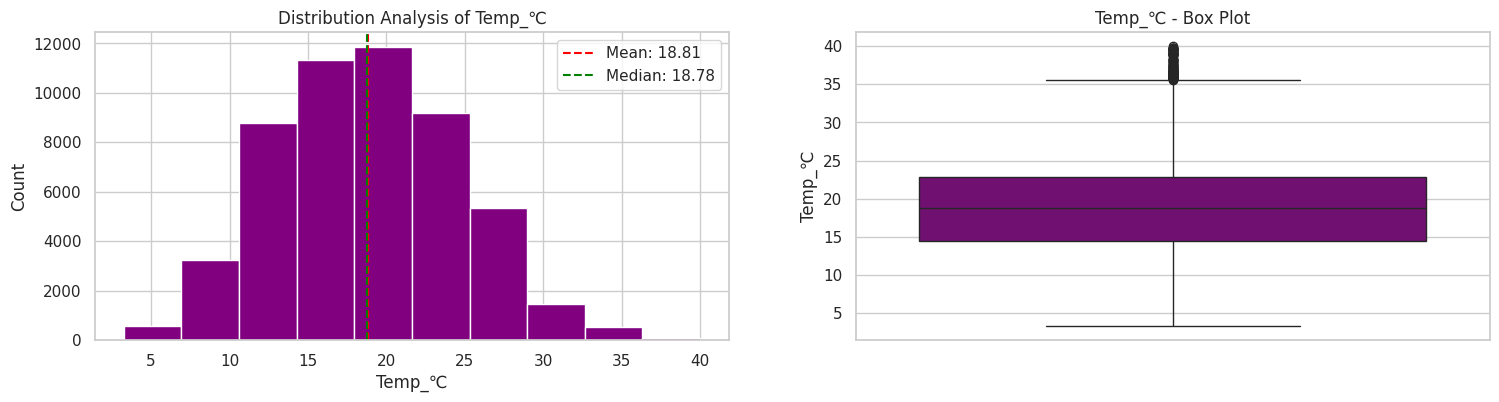

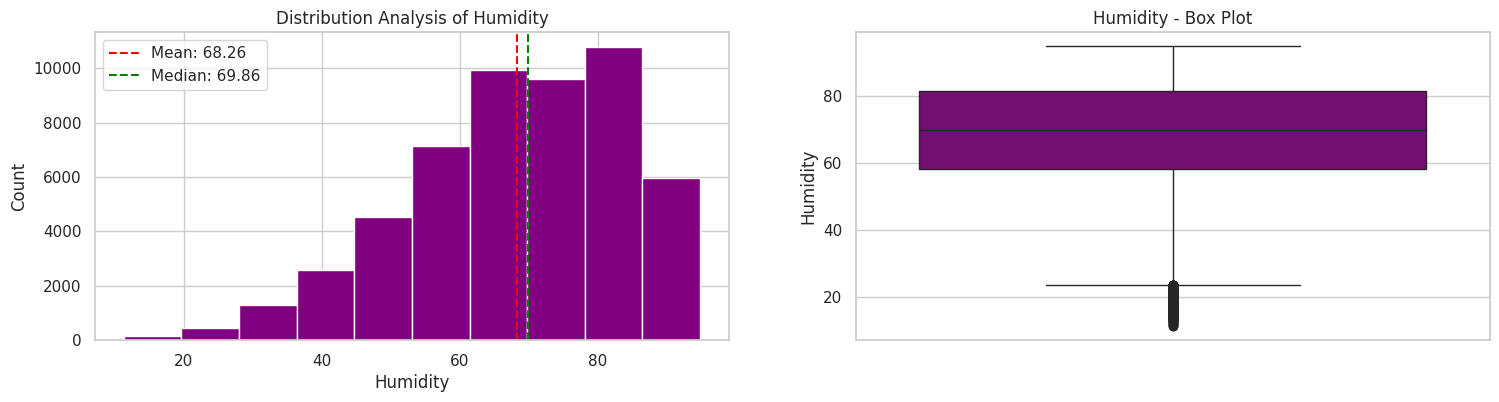

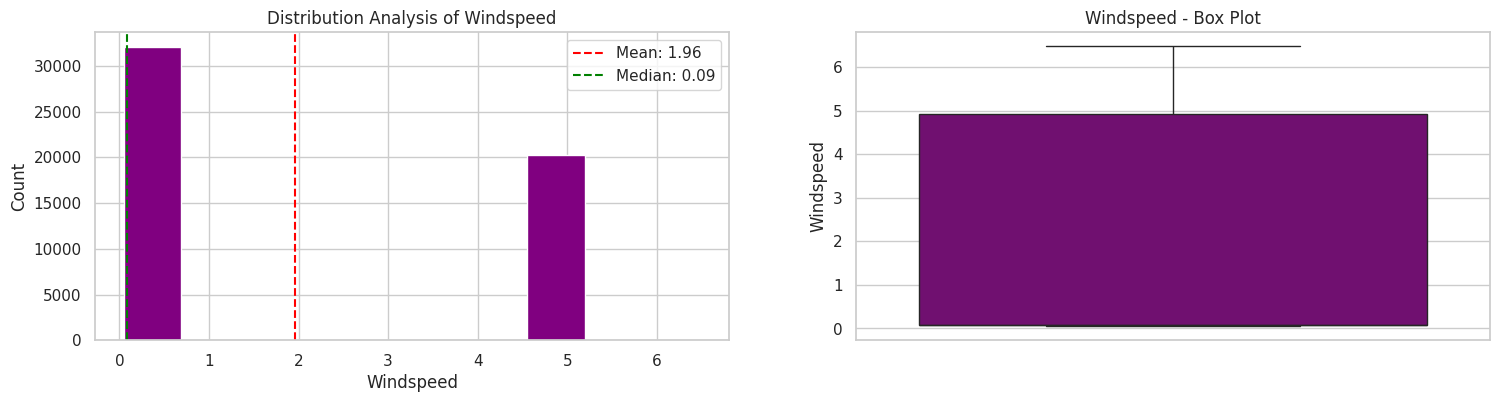

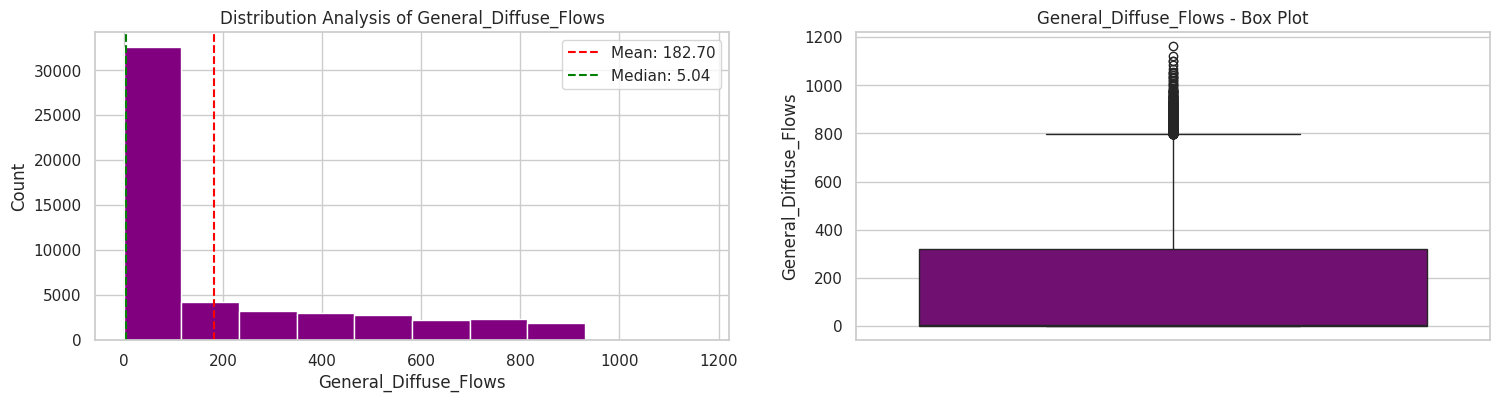

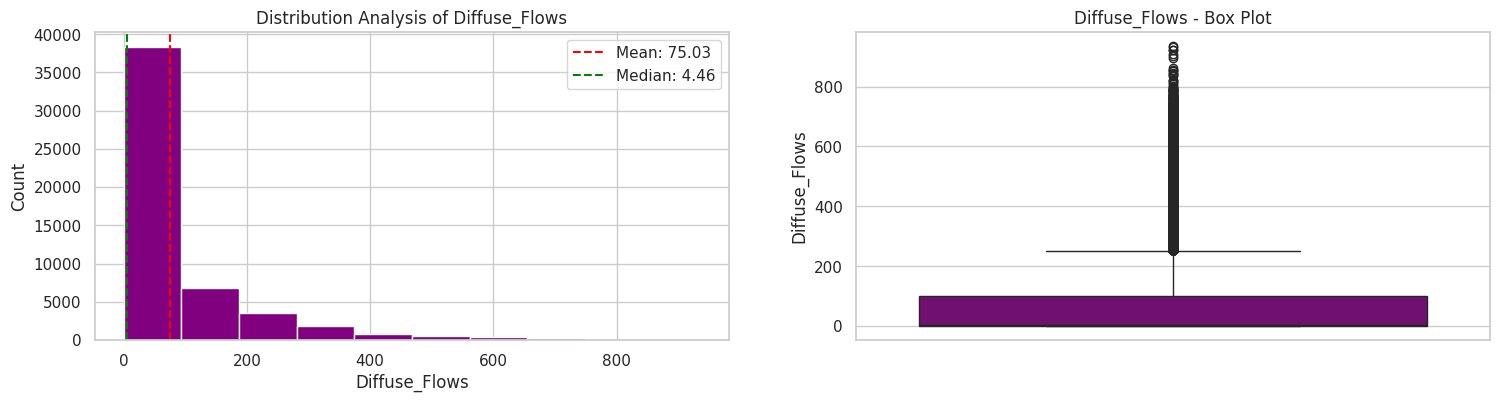

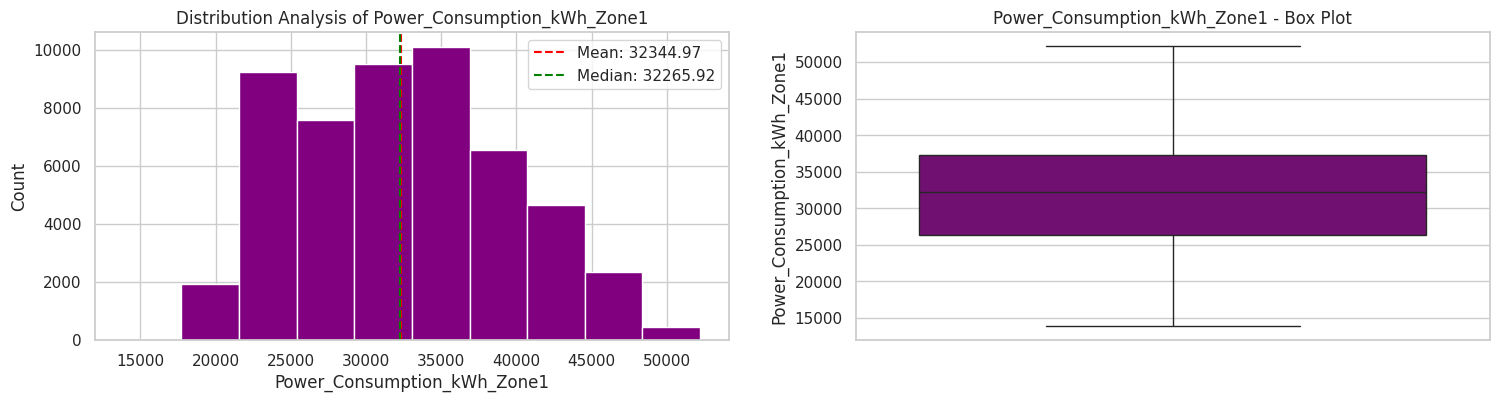

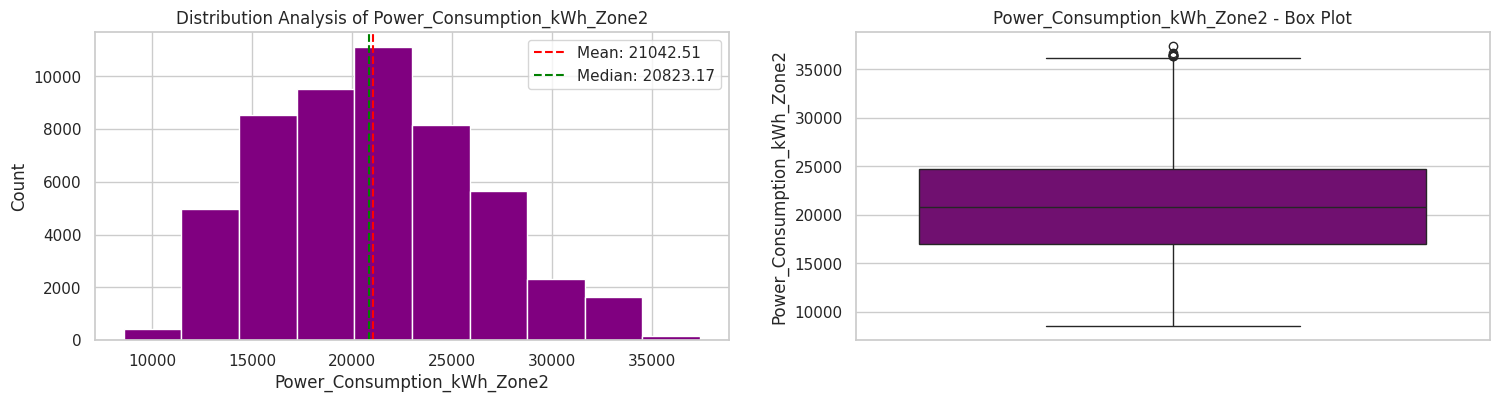

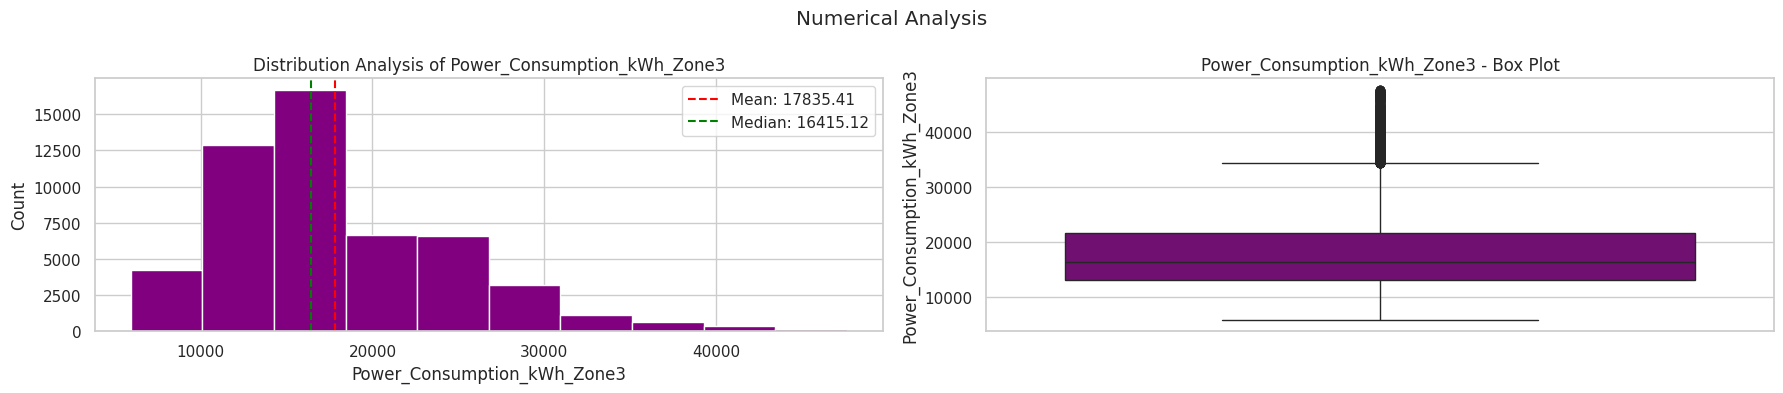

In [35]:
numerical_col =["Temp_℃", "Humidity", "Windspeed", "General_Diffuse_Flows","Diffuse_Flows", "Power_Consumption_kWh_Zone1", "Power_Consumption_kWh_Zone2", "Power_Consumption_kWh_Zone3"]

for col in numerical_col:
    fig, axes = plt.subplots(1, 2, figsize=(18,4))
    axes = axes.flatten()
    #histogram
    axes[0].hist(df[col].dropna(), color="purple")
    axes[0].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[0].axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[0].set_title(f"Distribution Analysis of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")
    axes[0].legend()

    #boxplot
    sns.boxplot(y=df[col], ax=axes[1], color="purple")
    axes[1].set_title(f"{col} - Box Plot")
    axes[1].set_ylabel(col)

plt.suptitle("Numerical Analysis")
plt.tight_layout()
plt.show()

In [36]:
print("Statiscal summary for numerical columns:")
for col in numerical_col:
    print(f"{'='*40}")
    print(f"Column: {col}")
    print(f"Std:      {df[col].std():.2f}")
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurt():.2f}")
    print(f"Min:      {df[col].min():.2f}")
    print(f"Max:      {df[col].max():.2f}")

Statiscal summary for numerical columns:
Column: Temp_℃
Std:      5.82
Skewness: 0.20
Kurtosis: -0.30
Min:      3.25
Max:      40.01
Column: Humidity
Std:      15.55
Skewness: -0.63
Kurtosis: -0.12
Min:      11.34
Max:      94.80
Column: Windspeed
Std:      2.35
Skewness: 0.46
Kurtosis: -1.78
Min:      0.05
Max:      6.48
Column: General_Diffuse_Flows
Std:      264.40
Skewness: 1.31
Kurtosis: 0.40
Min:      0.00
Max:      1163.00
Column: Diffuse_Flows
Std:      124.21
Skewness: 2.46
Kurtosis: 7.00
Min:      0.01
Max:      936.00
Column: Power_Consumption_kWh_Zone1
Std:      7130.56
Skewness: 0.23
Kurtosis: -0.75
Min:      13895.70
Max:      52204.40
Column: Power_Consumption_kWh_Zone2
Std:      5201.47
Skewness: 0.33
Kurtosis: -0.44
Min:      8560.08
Max:      37408.86
Column: Power_Consumption_kWh_Zone3
Std:      6622.17
Skewness: 1.02
Kurtosis: 1.09
Min:      5935.17
Max:      47598.33


#### Univariate Analysis Report
1. Temperature:
- The distribution is nearly symmetical / normal distribution (skew of 0.2 is close to 0)
- Mean and median are almost identical, confirming no significant skew
- Negative kurtosis (-0.3) means the distribution is slightly flatter than normal - temp are spread evenly across the range
- Range of temp suggests the dataset covers all four seasons
- The boxplot shoes no extreme outliers, temp behaves preditabaly
> Engineerin insight: The 40℃ peak likely corresponds to summer coolinf loads, while the 3.25℃ minimun suggests winter heating demands; both being major drivers of electricity consumption in residential and commercial zones
2. Humidity
- Negatively skewed (-0.63) meaning most readings are concentrated at higher humidity levels
- Median (69.86) is higher than mean (68.26) — confirms left skew
- Near-zero kurtosis (-0.12) suggests a fairly normal spread
- High std of 15.55 indicates significant humidity variation throughout the year
- Boxplot shows a single outlier at the very low end — likely an extreme dry day
> Engineering Insight: High humidity levels dominate this dataset. From an electrical standpoint, high humidity increases thermal discomfort, which in turn drives more HVAC usage. The outlier at 11.34% could represent an anomalous dry weather event worth investigating further.
 3. Windspeed
- This is the most unusual distribution in the dataset
- The massive gap between mean (1.96) and median (0.09) is a red flag
- Very high negative kurtosis (-1.78) — this is a bimodal/flat distribution
- Looking at the histogram this is confirmed — there are two distinct peaks: one near 0 and another around 5
- Skew of 0.46 indicates a right tail
> Engineering Insight: The bimodal windspeed distribution suggests the city experiences either very calm conditions or notably windy periods with little in between. This could be a geographical/seasonal pattern — possibly sea breezes or seasonal winds. For power consumption, high winds typically reduce cooling loads but this effect may be secondary to temperature in this dataset. The near-zero median suggests calm days dominate.
4. General Diffuse Flows
- Extreme gap between mean (182.70) and median (5.04) indicates severe right skew
- Skew of 1.31 confirms this — most readings cluster near zero with occasional very high values
- The histogram shows a classic J-shaped distribution — majority of values at 0
- Boxplot shows numerous outliers at the high end reaching 1163
- This pattern is consistent with solar irradiance data — zero at night, high peaks during sunny days
> Engineering Insight: The near-zero median (5.04) versus mean (182.70) tells us that diffuse solar radiation is absent for most of the day (nighttime hours). The high values represent peak solar activity during daylight hours. This has direct implications for solar energy contribution and cooling loads — high diffuse flows correlate with higher temperatures and thus higher power consumption.
5. Diffuse Flows
- Most skewed variable in the dataset (skew: 2.46)
- Extremely high kurtosis (7.0) — this is a leptokurtic distribution with a very sharp peak and heavy tails
- Median of 4.46 vs mean of 75.03 — values are overwhelmingly low with extreme spikes
- Boxplot shows the distribution is almost entirely compressed at the bottom with outliers extending to 936
- Similar pattern to General Diffuse Flows but more extreme
> Engineering Insight: The kurtosis of 7.0 is particularly noteworthy — it signals frequent extreme solar radiation events. These brief but intense spikes in diffuse flow likely correspond to peak solar hours in summer months. For power grid management, these spikes are critical as they coincide with peak cooling demand periods.
6. Power Consumption Zone 1
- Most normally distributed of the three zones (skew: 0.23, nearly symmetric)
- Mean and median are very close — stable, predictable consumption pattern
- Negative kurtosis (-0.75) means consumption is spread broadly without extreme peaks
- Highest mean consumption of all three zones (32,344.97 kWh)
- Boxplot shows no significant outliers — Zone 1 is the most stable zone
> Engineering Insight:  Zone 1 represents the largest and most consistent power consumer in the dataset. The near-normal distribution suggests this zone likely represents industrial or large commercial loads that operate relatively consistently throughout the day. The wide range (13,895 to 52,204 kWh) still indicates significant day/night and seasonal variation.
7. Power Consumption Zone 2
- Slightly right skewed (0.33) — occasional high consumption periods
- Mean and median are close — relatively stable consumption
- Negative kurtosis (-0.44) — flat distribution, consumption is spread across a wide range
- Lowest std of the three zones (5,201.47) — most consistent zone
> Engineering Insight: Zone 2 shows the most consistent consumption pattern with the lowest standard deviation. This likely represents a mixed residential/commercial zone. The single high outlier could represent a specific event — a festival, industrial activity, or data error that should be flagged for further investigation.
8. Power Consumption Zone 3
- Most skewed power consumption zone (skew: 1.02)
- Notable gap between mean (17,835) and median (16,415) — right skewed
- Positive kurtosis (1.09) — more peaked than normal with heavy tails
- Has the lowest minimum (5,935 kWh) but second highest maximum (47,598 kWh)
- Boxplot shows outliers at both extremes — most notable at the very high end
> Engineering Insight: Zone 3 is the most volatile consumption zone. The high skew and kurtosis suggest irregular usage patterns — possibly a zone with seasonal industries, agricultural loads, or variable commercial activity. The extreme range (5,935 to 47,598 kWh) is the largest proportional variation of all three zones and warrants closer monitoring.

 Overall Summary
| Variable | Distribution Shape | Key Finding |
|---|---|---|
| Temperature | Normal | Seasonal range, drives consumption |
| Humidity | Left skewed | Mostly high, one dry outlier |
| Windspeed | Bimodal | Calm or windy, rarely in between |
| General Diffuse Flows | Heavily right skewed | Solar pattern, zero at night |
| Diffuse Flows | Extremely right skewed | Intense solar spikes (kurt=7) |
| Zone 1 Power | Near normal | Largest, most stable consumer |
| Zone 2 Power | Near normal | Most consistent, one outlier |
| Zone 3 Power | Right skewed | Most volatile, needs monitoring |


### 5. Univariate Analysis - Categorical Feature

In [37]:
df1 = df.drop(columns=["Month", "Day"])
df_daily = df_hourly_avg.set_index("Datetime").resample("1D").agg({
    "Temp_℃": "mean",        # average temp for the day
    "Humidity": "mean",        # average humidity
    "Windspeed": "mean",       # average windspeed
    "General_Diffuse_Flows": "mean",
    "Diffuse_Flows": "mean",
    "Power_Consumption_kWh_Zone1": "sum",  # total daily consumption
    "Power_Consumption_kWh_Zone2": "sum",
    "Power_Consumption_kWh_Zone3": "sum",
}).reset_index()

df_daily["Month"] = df_daily["Datetime"].dt.month_name()
df_daily["Day"] = df_daily["Datetime"].dt.day_name()
df_daily.describe(include="object")

C:\Users\push\AppData\Local\Temp\ipykernel_2272\380999712.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_daily.describe(include="object")


,Month,Day
count,364,364
unique,12,7
top,January,Sunday
freq,31,52


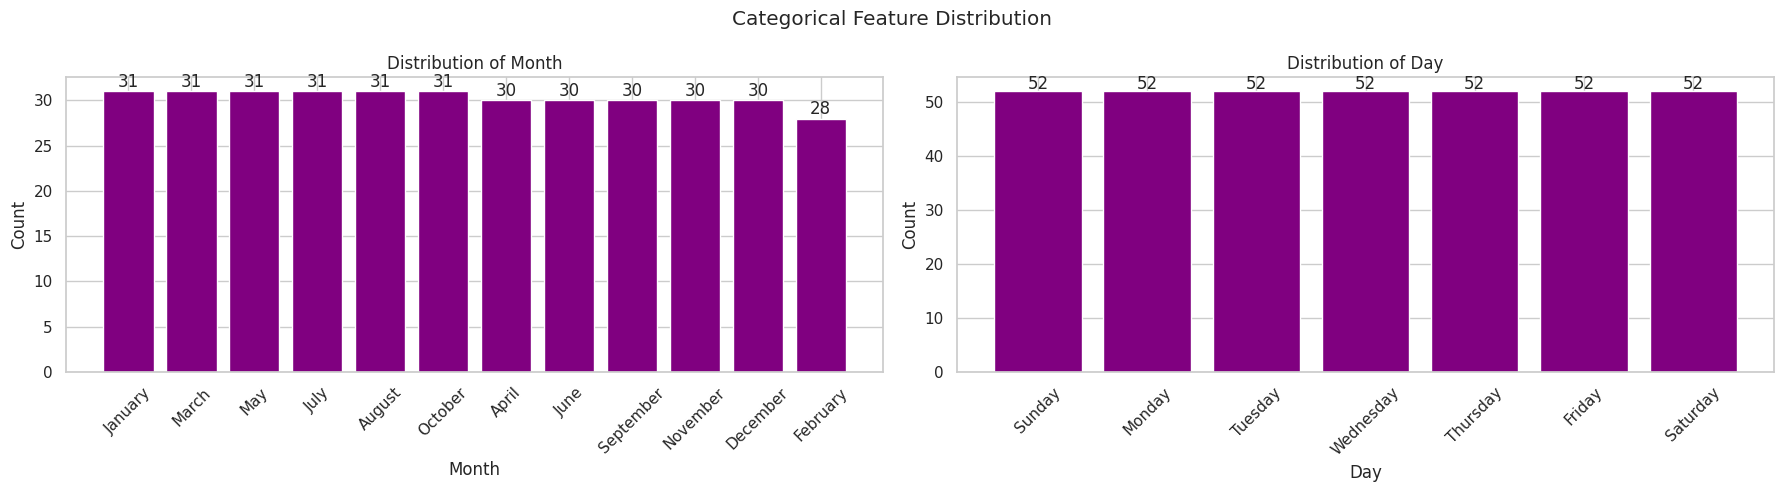

In [59]:
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
df_daily["Month"] = pd.Categorical(df_daily["Month"], categories=month_order, ordered=True)
categorical_col = ["Month", "Day"]
fig, axes = plt.subplots(1, 2, figsize=(18,5))
for i, col in enumerate(categorical_col):
    counts = df_daily[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color="purple")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 0.5, str(v), ha="center")
plt.suptitle("Categorical Feature Distribution")
plt.tight_layout()
plt.show()

### 6. Bivariate Analysis

In [69]:
df.groupby("Day")["Power_Consumption_kWh_Zone1"].mean().sort_values(ascending=False)

Day
Wednesday   32,871.759
Thursday    32,842.484
Tuesday     32,713.030
Monday      32,615.411
Friday      32,338.996
Saturday    32,253.034
Sunday      30,780.079
Name: Power_Consumption_kWh_Zone1, dtype: float64

In [68]:
df.groupby("Day")["Power_Consumption_kWh_Zone2"].mean().sort_values(ascending=False)

Day
Thursday    21,845.164
Wednesday   21,627.363
Tuesday     21,518.600
Friday      21,461.038
Monday      21,280.065
Saturday    20,585.956
Sunday      18,979.377
Name: Power_Consumption_kWh_Zone2, dtype: float64

In [67]:
df.groupby("Day")["Power_Consumption_kWh_Zone3"].mean().sort_values(ascending=False)

Day
Saturday    18,011.187
Sunday      17,954.828
Wednesday   17,851.395
Thursday    17,843.692
Tuesday     17,831.688
Monday      17,809.082
Friday      17,545.971
Name: Power_Consumption_kWh_Zone3, dtype: float64

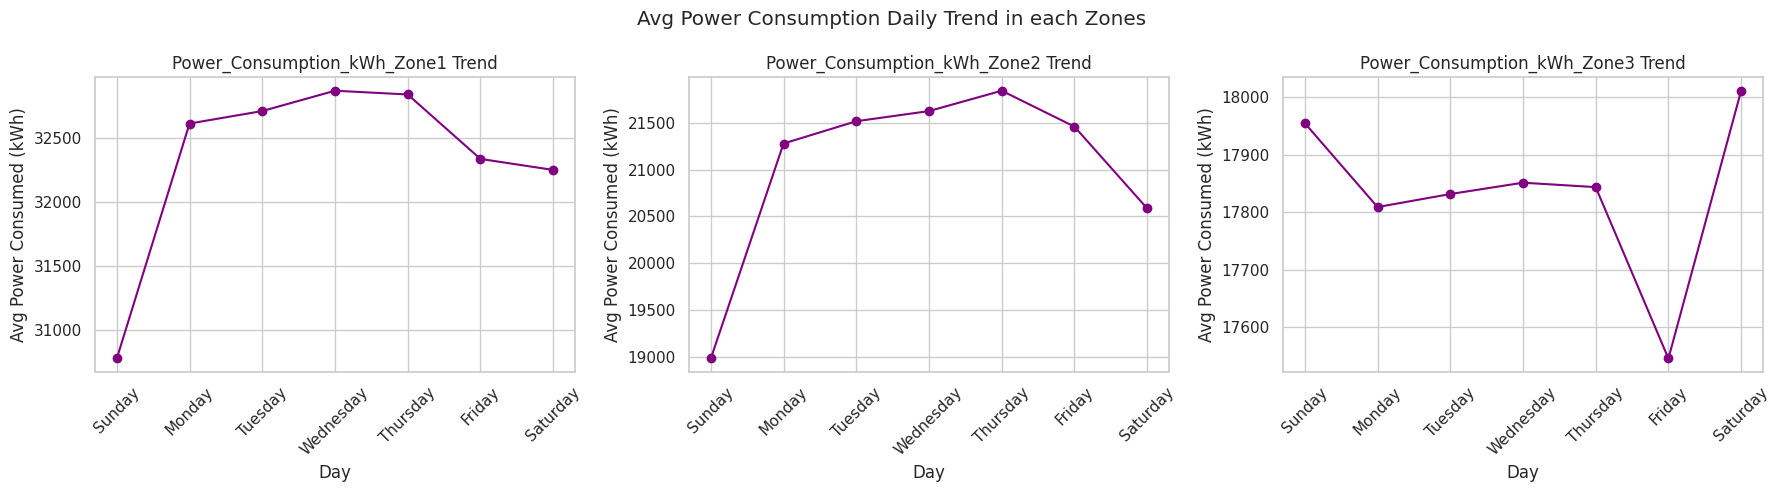

In [70]:
zones = ["Power_Consumption_kWh_Zone1", "Power_Consumption_kWh_Zone2", "Power_Consumption_kWh_Zone3"]
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
df["Day"] = pd.Categorical(df["Day"], categories=day_order, ordered=True)
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, zone in zip(axes, zones):
    daily_power = df.groupby("Day")[zone].mean().sort_index()
    ax.plot(daily_power.index, daily_power.values, marker="o", color="purple")
    ax.set_title(f"{zone} Trend")
    ax.set_xlabel("Day")
    ax.set_ylabel("Avg Power Consumed (kWh)")
    ax.set_xticks(range(len(day_order)))
    ax.set_xticklabels(day_order, rotation=45)
    ax.grid(True)
plt.suptitle("Avg Power Consumption Daily Trend in each Zones")
plt.tight_layout()
plt.show()

From the data, it shows that weekdays has higher power consumed in the zone 1 & 2 area compared to the weekends. This suggests that zone 1 & 2 is more of a residential area since more power is consumed during the weekdays and less during the weekends as industrial/commercial areas do not operate in the weekend.
Zone 2 shows the exact opposite, this would require further investigation to the reason why.
Also zone 1 avg power consumption is noteably higher than the two other zones

In [64]:
df_daily.groupby("Month")["Power_Consumption_kWh_Zone1"].sum().sort_values(ascending=False)

Month
August      27,107,781.062
July        26,658,675.890
June        24,915,989.392
October     24,423,779.092
May         24,102,630.828
September   24,045,610.625
March       23,179,443.061
January     23,088,175.189
April       22,442,233.103
December    20,897,401.282
November    20,881,516.938
February    20,822,426.425
Name: Power_Consumption_kWh_Zone1, dtype: float64

In [65]:
df_daily.groupby("Month")["Power_Consumption_kWh_Zone2"].sum().sort_values(ascending=False)

Month
August      18,344,225.140
July        17,966,027.845
December    17,050,934.036
November    16,733,134.093
October     15,972,931.127
June        14,883,068.608
May         14,863,102.166
September   14,529,911.214
January     14,429,466.870
March       13,732,705.478
April       12,696,455.810
February    12,625,396.969
Name: Power_Consumption_kWh_Zone2, dtype: float64

In [66]:
df_daily.groupby("Month")["Power_Consumption_kWh_Zone3"].sum().sort_values(ascending=False)

Month
July        20,976,418.751
August      18,338,777.685
June        14,710,277.916
April       13,387,080.734
January     13,203,094.942
May         13,110,099.108
March       12,609,078.391
February    11,649,121.451
September   10,744,415.123
October      9,868,486.818
November     9,260,997.597
December     7,952,260.267
Name: Power_Consumption_kWh_Zone3, dtype: float64

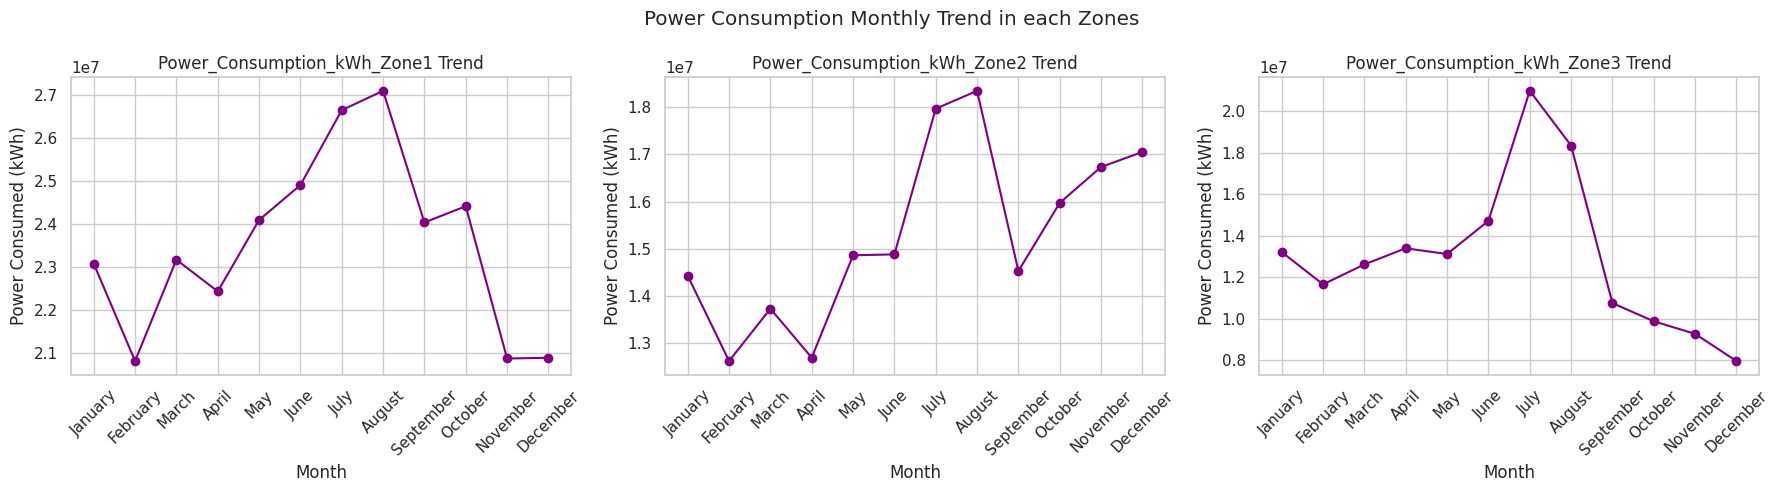

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, zone in zip(axes, zones):
    monthly_power = df_daily.groupby("Month")[zone].sum().sort_index()
    ax.plot(monthly_power.index, monthly_power.values, marker="o", color="purple")
    ax.set_title(f"{zone} Trend")
    ax.set_xlabel("Month")
    ax.set_ylabel("Power Consumed (kWh)")
    ax.set_xticks(range(len(month_order)))
    ax.set_xticklabels(month_order, rotation=45)
    ax.grid(True)
plt.suptitle("Power Consumption Monthly Trend in each Zones")
plt.tight_layout()
plt.show()

From the monthly trends, power is consumed mos in July and August for each zones while the last quarter sees a raplid fall in the consumption of power except in zone 2 where it actually rises.
Zone 1 has the highest power consumption compared to the two other zones as even the least pwer consumed in a month for zone 1 is higher than the most power consunmed for zone 2 and its approx fpr zone 3.

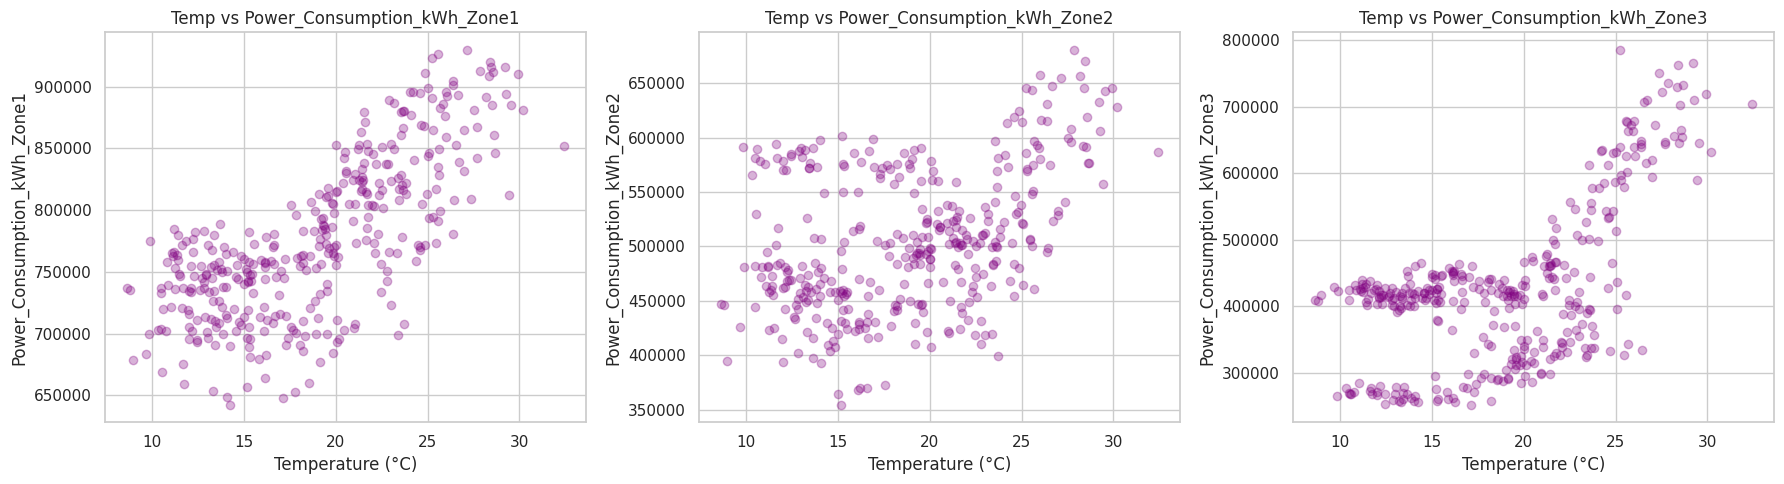

In [46]:
# 1. Scatter plot - Temp vs Zones
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, zone in enumerate(zones):
    axes[i].scatter(df_daily["Temp_℃"], df_daily[zone], alpha=0.3, color="purple")
    axes[i].set_xlabel("Temperature (°C)")
    axes[i].set_ylabel(zone)
    axes[i].set_title(f"Temp vs {zone}")

plt.tight_layout()
plt.show()


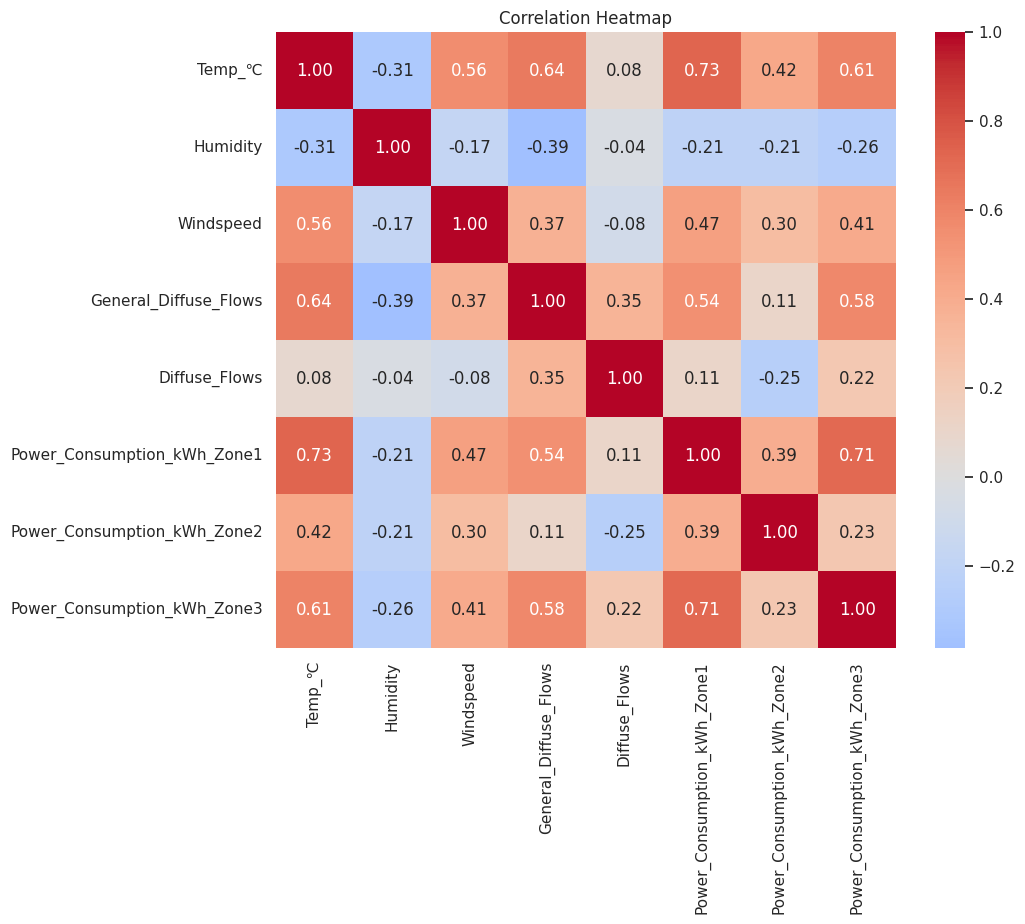

In [47]:
# 2. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    df_daily.select_dtypes(include="number").corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0)
plt.title("Correlation Heatmap")
plt.show()


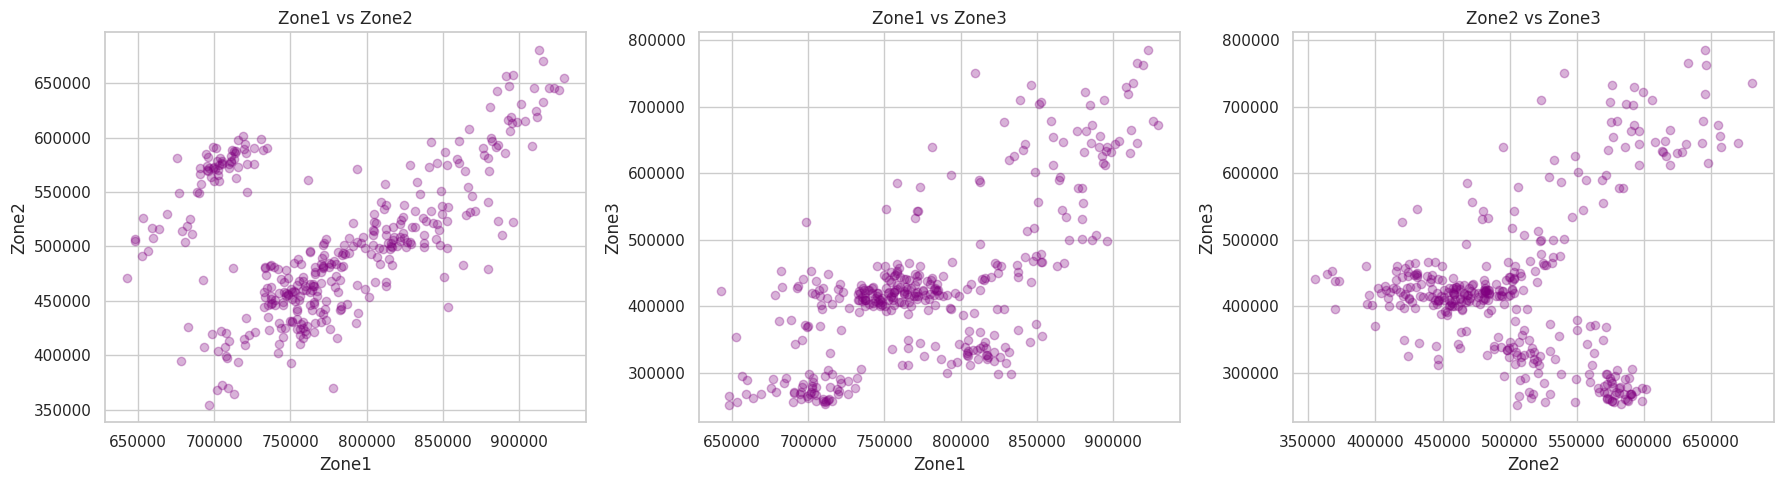

In [52]:
# 3. Zone vs Zone comparison
fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes[0].scatter(df_daily["Power_Consumption_kWh_Zone1"], df_daily["Power_Consumption_kWh_Zone2"], alpha=0.3, color="purple")
axes[0].set_xlabel("Zone1")
axes[0].set_ylabel("Zone2")
axes[0].set_title("Zone1 vs Zone2")

axes[1].scatter(df_daily["Power_Consumption_kWh_Zone1"], df_daily["Power_Consumption_kWh_Zone3"], alpha=0.3, color="purple")
axes[1].set_xlabel("Zone1")
axes[1].set_ylabel("Zone3")
axes[1].set_title("Zone1 vs Zone3")

axes[2].scatter(df_daily["Power_Consumption_kWh_Zone2"], df_daily["Power_Consumption_kWh_Zone3"], alpha=0.3, color="purple")
axes[2].set_xlabel("Zone2")
axes[2].set_ylabel("Zone3")
axes[2].set_title("Zone2 vs Zone3")
plt.tight_layout()
plt.show()
